# Discounted-obstacle implicit BSDE and stopping-time value

This notebook is a copy of `implicit_bsde_binomial_solvers.ipynb` adapted to the zero-driver formulation of the American put problem. The discounted obstacle is

$$S_t=e^{-rt}(X_t-K)^-=e^{-rt}(K-X_t)^+,$$

and the regularized generator contains no $-rY$ term:

$$f_\varepsilon(t,X_t,Y_t^\varepsilon)=\phi(Y_t^\varepsilon-S_t,\varepsilon)\,e^{-rt}rK\mathbf{1}_{\{X_t\le K\}}.$$

For each observation grid, the code also evaluates

$$\tau_0^\varepsilon=\inf\{u\in[0,T]:Y_u^\varepsilon\le S_u+\varepsilon\}\wedge T$$

and computes the unconditional value $\mathbb{E}_0[S_{\tau_0^\varepsilon}]$ by backward dynamic programming on the same binomial tree. These quantities define the stopping-time interval and value interval

$$[Y^{\mathtt{ST},\varepsilon,h}_{t_0}-\tfrac{\varepsilon}{2},\,Y^{\mathtt{ST},\varepsilon,h}_{t_0}+\tfrac{\varepsilon}{2}],\qquad [Y^{\mathtt{V},\varepsilon,h}_{t_0}-\tfrac{\varepsilon}{2},\,Y^{\mathtt{V},\varepsilon,h}_{t_0}+\tfrac{\varepsilon}{2}].$$

The left panel plots the four interval boundaries and the reference value $Y_{t_0}$. The right panel plots their signed relative errors together with the two corresponding midpoint estimates $Y^{\mathtt{ST},\varepsilon,h}_{t_0}$ and $Y^{\mathtt{V},\varepsilon,h}_{t_0}$. The mixed midpoint is intentionally omitted from the figure.

In [1]:
from dataclasses import dataclass
from functools import lru_cache
from typing import Literal
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "axes.grid": True,
    "grid.linestyle": ":",
})

## Configuration

Set product and model parameters once in `ModelParams`. Each experiment can then vary the implicit solver, observation counts, and epsilon scaling without touching the solver implementation.

In [2]:
# The Literal alias documents the allowed implicit solvers.
ImplicitSolver = Literal["picard", "bisection", "newton"]


@dataclass(frozen=True)
class ModelParams:
    """Market, contract, and binomial-tree parameters used by every run."""

    # Contract inputs.
    S0: float = 100.0
    K: float = 100.0
    T: float = 1.0

    # Market inputs under the risk-neutral model.
    r: float = 0.02
    sigma: float = 0.2

    # N_fine drives the underlying CRR tree used by the sparse-observation BSDE.
    # N_reference is used only for the benchmark CRR price.
    N_fine: int = 2**15
    N_reference: int = 2**15


@dataclass(frozen=True)
class GeneratorConfig:
    """Select the regularization-width scaling."""

    # epsilon(dt) = epsilon_constant * dt**epsilon_power.
    epsilon_constant: float = 1.0
    epsilon_power: float = 3 / 8

    def epsilon(self, dt_obs: float) -> float:
        """Evaluate the observation-step dependent scaling parameter."""
        return self.epsilon_constant * dt_obs ** self.epsilon_power

    def label(self) -> str:
        """Legend label for the selected epsilon scaling."""
        return (
            rf"$\varepsilon={self.epsilon_constant:g}"
            rf"\Delta t^{{{self.epsilon_power:g}}}$"
        )


@dataclass(frozen=True)
class ExperimentConfig:
    """Bundle one stopping-time experiment."""

    model: ModelParams
    generator: GeneratorConfig
    implicit_solver: ImplicitSolver = "newton"

    # N_obs_grid controls how many observation dates the BSDE uses. Larger
    # values mean a smaller observation step and should reduce discretization error.
    N_obs_grid: tuple[int, ...] = (64, 128, 256, 512, 1024, 2048)


SOLVER_LABELS = {
    "picard": "Picard iteration",
    "bisection": "bisection method",
    "newton": "Newton's method",
}

BOUNDARY_STYLES = {
    "st": dict(color="tab:blue", marker="o", linestyle="-"),
    "v": dict(color="tab:orange", marker="s", linestyle="-"),
}
MIDPOINT_STYLES = {
    "st": dict(color="tab:blue", marker="D", linestyle=(0, (3, 3))),
    "v": dict(color="tab:orange", marker="^", linestyle=(0, (3, 3))),
}
PLOT_STYLES = {
    "st_lower": BOUNDARY_STYLES["st"],
    "st_upper": BOUNDARY_STYLES["st"],
    "st_midpoint": MIDPOINT_STYLES["st"],
    "v_lower": BOUNDARY_STYLES["v"],
    "v_upper": BOUNDARY_STYLES["v"],
    "v_midpoint": MIDPOINT_STYLES["v"],
}
PLOT_LABELS = {
    "st_lower": r"$Y^{\mathtt{ST},\varepsilon,h}_{t_0}-\frac{\varepsilon}{2}$",
    "st_upper": r"$Y^{\mathtt{ST},\varepsilon,h}_{t_0}+\frac{\varepsilon}{2}$",
    "st_midpoint": r"$Y^{\mathtt{ST},\varepsilon,h}_{t_0}$",
    "v_lower": r"$Y^{\mathtt{V},\varepsilon,h}_{t_0}-\frac{\varepsilon}{2}$",
    "v_upper": r"$Y^{\mathtt{V},\varepsilon,h}_{t_0}+\frac{\varepsilon}{2}$",
    "v_midpoint": r"$Y^{\mathtt{V},\varepsilon,h}_{t_0}$",
}

## CRR references and binomial-grid helpers

In [3]:
def crr_discounted_obstacle_value(S0, K, T, r, sigma, N):
    """CRR Snell-envelope value for the already-discounted put obstacle."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    q = (np.exp(r * dt) - d) / (u - d)

    j = np.arange(N + 1)
    stock = S0 * u**j * d**(N - j)
    V = np.exp(-r * T) * np.maximum(K - stock, 0.0)

    # The obstacle is already discounted to time 0, so continuation uses
    # a plain risk-neutral conditional expectation with no extra discount.
    for n in range(N - 1, -1, -1):
        V = (1.0 - q) * V[:-1] + q * V[1:]
        j = np.arange(n + 1)
        stock = S0 * u**j * d**(n - j)
        t = n * dt
        exercise = np.exp(-r * t) * np.maximum(K - stock, 0.0)
        V = np.maximum(V, exercise)
    return float(V[0])


def reference_price(model: ModelParams) -> float:
    """Reference binomial-tree value Y_0 for the discounted obstacle."""
    return crr_discounted_obstacle_value(
        model.S0, model.K, model.T, model.r, model.sigma, model.N_reference
    )


@lru_cache(maxsize=None)
def binomial_probabilities(m: int, q: float) -> np.ndarray:
    """Probability mass for the number of up moves over m fine tree steps."""
    ell = np.arange(m + 1)
    probs = binom.pmf(ell, m, q)
    probs /= probs.sum()  # Normalize away tiny floating-point drift.
    return probs


def multi_step_conditional_expectation(Y_next: np.ndarray, m: int, q: float) -> np.ndarray:
    """Compute E[Y_next | current node] across m skipped fine steps."""
    # Each current node has m+1 descendants on the next observation slice.
    # Correlation slides the binomial weights across each descendant window.
    probs = binomial_probabilities(m, q)
    return np.correlate(Y_next, probs, mode="valid")


def observation_indices(N_fine: int, N_obs: int) -> np.ndarray:
    """Map the coarse observation grid onto integer levels of the fine tree."""
    idx = np.rint(np.linspace(0, N_fine, N_obs + 1)).astype(int)
    idx[0] = 0
    idx[-1] = N_fine
    if np.any(np.diff(idx) <= 0):
        raise ValueError("Observation grid has repeated indices. Increase N_fine or reduce N_obs.")
    return idx

## Generator functions

In [4]:
def smooth_cutoff(x: np.ndarray) -> np.ndarray:
    """Smooth switch: 1 for x <= 0, 0 for x >= 1, smooth in between."""
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    out[x <= 0.0] = 1.0
    mid = (x > 0.0) & (x < 1.0)

    def _f(t: np.ndarray) -> np.ndarray:
        return np.exp(-1.0 / t)

    # Only evaluate the transition formula where 0 < x < 1.
    fx = _f(x[mid])
    f1mx = _f(1.0 - x[mid])
    out[mid] = f1mx / (fx + f1mx)
    return out


def phi(x: np.ndarray, epsilon: float) -> np.ndarray:
    """Scale the smooth cutoff by the width epsilon."""
    if epsilon <= 0.0:
        raise ValueError("epsilon must be positive.")
    return smooth_cutoff(x / epsilon)


def discounted_obstacle(t: float, stock: np.ndarray, model: ModelParams) -> np.ndarray:
    """Evaluate S_t = exp(-rt) (K-X_t)^+ at every stock node."""
    return np.exp(-model.r * t) * np.maximum(model.K - stock, 0.0)


def regularized_generator(
    t: float,
    stock: np.ndarray,
    Y: np.ndarray,
    model: ModelParams,
    obstacle: np.ndarray,
    epsilon: float,
) -> np.ndarray:
    """Regularized driver with zero base generator (no -rY term)."""
    # Discounting the put obstacle also discounts its drift magnitude.
    pen = np.exp(-model.r * t) * model.r * model.K
    pen = pen * (stock <= model.K).astype(float)
    return phi(Y - obstacle, epsilon) * pen


def implicit_residual(
    Y: np.ndarray,
    base: np.ndarray,
    stock: np.ndarray,
    t: float,
    model: ModelParams,
    dt: float,
    obstacle: np.ndarray,
    epsilon: float,
) -> np.ndarray:
    """Residual of Y = base + dt*f_epsilon(t,X,Y)."""
    return Y - base - dt * regularized_generator(
        t, stock, Y, model, obstacle, epsilon
    )

## Implicit solvers

In [5]:
def picard(
    base: np.ndarray,
    stock: np.ndarray,
    t: float,
    model: ModelParams,
    dt: float,
    obstacle: np.ndarray,
    epsilon: float,
    Y_init: np.ndarray | None = None,
    tol: float = 1e-8,
    max_iter: int = 500,
    relaxation: float = 1.0,
) -> np.ndarray:
    """Fixed-point iteration for Y = base + dt*f_epsilon(t,X,Y)."""
    Y = base.copy() if Y_init is None else Y_init.copy()
    for _ in range(max_iter):
        # Freeze Y inside the generator, then update the current iterate.
        Y_candidate = base + dt * regularized_generator(
            t, stock, Y, model, obstacle, epsilon
        )
        Y_new = (1.0 - relaxation) * Y + relaxation * Y_candidate
        if np.max(np.abs(Y_new - Y)) < tol:
            return Y_new
        Y = Y_new
    raise RuntimeError("Picard iteration did not converge within max_iter steps.")


def bisection(
    base: np.ndarray,
    stock: np.ndarray,
    t: float,
    model: ModelParams,
    dt: float,
    obstacle: np.ndarray,
    epsilon: float,
    tol: float = 1e-12,
    max_iter: int = 500,
) -> np.ndarray:
    """Nodewise bisection for the root of the implicit residual."""
    # Put values are nonnegative; a generous upper bound gives the
    # regularization term room to move the root.
    lo = np.zeros_like(base) - tol
    hi = np.maximum(
        np.full_like(base, model.K) + tol,
        np.asarray(base) + model.K + 10.0,
    )

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        g_mid = implicit_residual(
            mid, base, stock, t, model, dt, obstacle, epsilon
        )

        # If residual(mid) <= 0, the root is to the right; otherwise it is left.
        lo = np.where(g_mid <= 0.0, mid, lo)
        hi = np.where(g_mid > 0.0, mid, hi)
        if np.max(hi - lo) < tol:
            break
    return 0.5 * (lo + hi)


def newton(
    base: np.ndarray,
    stock: np.ndarray,
    t: float,
    model: ModelParams,
    dt: float,
    obstacle: np.ndarray,
    epsilon: float,
    Y_init: np.ndarray | None = None,
    tol: float = 1e-8,
    max_iter: int = 200,
) -> np.ndarray:
    """Nodewise Newton method using a centered finite-difference derivative."""
    Y = base.copy() if Y_init is None else Y_init.copy()
    for _ in range(max_iter):
        g = implicit_residual(Y, base, stock, t, model, dt, obstacle, epsilon)

        # The finite-difference step scales with |Y| but stays nonzero near 0.
        h = 1e-5 * np.maximum(1.0, np.abs(Y))
        derivative = (
            implicit_residual(Y + h, base, stock, t, model, dt, obstacle, epsilon)
            - implicit_residual(Y - h, base, stock, t, model, dt, obstacle, epsilon)
        ) / (2.0 * h)
        derivative = np.where(np.abs(derivative) < 1e-14, np.sign(derivative) * 1e-14 + 1e-14, derivative)

        Y_new = Y - g / derivative
        if np.max(np.abs(Y_new - Y)) < tol:
            return Y_new
        Y = Y_new
    raise RuntimeError("Newton iteration did not converge within max_iter steps.")


def solve_implicit_update(
    base: np.ndarray,
    stock: np.ndarray,
    t: float,
    model: ModelParams,
    dt: float,
    implicit_solver: ImplicitSolver,
    obstacle: np.ndarray,
    epsilon: float,
) -> np.ndarray:
    """Select the requested implicit solver for one backward time slice."""
    kwargs = dict(
        base=base, stock=stock, t=t, model=model, dt=dt,
        obstacle=obstacle, epsilon=epsilon,
    )
    if implicit_solver == "picard":
        return picard(**kwargs, Y_init=base)
    if implicit_solver == "bisection":
        return bisection(**kwargs)
    if implicit_solver == "newton":
        return newton(**kwargs, Y_init=base)
    raise ValueError(f"Unknown implicit solver={implicit_solver!r}.")

## Sparse-observation BSDE solver

In [6]:
def solve_regularized_bsde_and_stopping_value(
    model: ModelParams,
    config: GeneratorConfig,
    N_obs: int,
    implicit_solver: ImplicitSolver = "newton",
) -> dict:
    """Solve Y^epsilon and evaluate E_0[S_{tau_0^epsilon}]."""
    N_fine = model.N_fine
    dt_fine = model.T / N_fine
    if N_obs <= 0:
        raise ValueError("N_obs must be positive.")

    # The fine CRR tree supplies the stock dynamics between observation dates.
    u = np.exp(model.sigma * np.sqrt(dt_fine))
    d = 1.0 / u
    q = (np.exp(model.r * dt_fine) - d) / (u - d)

    if not (0.0 <= q <= 1.0):
        raise ValueError(f"Invalid risk-neutral probability q={q:.6f}.")

    obs_idx = observation_indices(N_fine, N_obs)
    epsilon = config.epsilon(model.T / N_obs)

    # Terminal condition equals the discounted obstacle at T. The stopping
    # value also equals the obstacle there because tau is capped at T.
    n_terminal = obs_idx[-1]
    j = np.arange(n_terminal + 1)
    stock = model.S0 * (u**j) * (d ** (n_terminal - j))
    obstacle = discounted_obstacle(model.T, stock, model)
    Y = obstacle.copy()
    stopping_value = obstacle.copy()

    # Move backward from the last observation date to time 0. Alongside
    # Y, propagate the payoff obtained by the first-contact rule.
    for k in range(N_obs - 1, -1, -1):
        n_now = obs_idx[k]
        n_next = obs_idx[k + 1]

        # m fine tree steps are aggregated into this one BSDE observation step.
        m = n_next - n_now
        dt_obs = m * dt_fine

        # Conditional expectations of Y and of the future first-contact payoff.
        base = multi_step_conditional_expectation(Y, m, q)
        continuation_stopping = multi_step_conditional_expectation(
            stopping_value, m, q
        )

        # Current stock nodes align with the current observation slice.
        j_now = np.arange(n_now + 1)
        stock_now = model.S0 * (u**j_now) * (d ** (n_now - j_now))
        t_now = n_now * dt_fine
        obstacle_now = discounted_obstacle(t_now, stock_now, model)

        # Solve Y_now = E[Y_next | F_now] + dt*f_epsilon(t,X,Y_now).
        Y = solve_implicit_update(
            base=base,
            stock=stock_now,
            t=t_now,
            model=model,
            dt=dt_obs,
            implicit_solver=implicit_solver,
            obstacle=obstacle_now,
            epsilon=epsilon,
        )

        # Stop at the current node on first contact; otherwise inherit the
        # conditional value of the first contact at a later observation date.
        contact_now = Y <= obstacle_now + epsilon
        stopping_value = np.where(
            contact_now, obstacle_now, continuation_stopping
        )

    return {
        "Y_epsilon_0": float(Y[0]),
        "expected_stopping_payoff": float(stopping_value[0]),
        "epsilon": float(epsilon),
    }

## Stopping-time experiment and side-by-side comparison panels

In [7]:
def run_stopping_time_experiment(
    exp: ExperimentConfig,
    verbose: bool = True,
) -> dict:
    """Evaluate values and signed relative errors over the observation grid."""
    model = exp.model
    N_obs_grid = np.asarray(exp.N_obs_grid, dtype=int)
    dt_obs_vals = model.T / N_obs_grid
    ref = reference_price(model)

    epsilon_vals = np.empty(len(N_obs_grid))
    stopping_vals = np.empty(len(N_obs_grid))
    Y_epsilon_vals = np.empty(len(N_obs_grid))
    t0 = time.perf_counter()

    if verbose:
        print("\n" + "=" * 94)
        print(f"Discounted-obstacle regularization with {SOLVER_LABELS[exp.implicit_solver]}")
        print(f"epsilon = {exp.generator.epsilon_constant:g} * dt_obs^{exp.generator.epsilon_power:g}")
        print(f"Fine tree steps: N_fine = {model.N_fine}")
        print(f"Reference tree steps: N_reference = {model.N_reference}")
        print(f"Reference Y_0 = {ref:.12f}")
        print("=" * 94)

    for k, N_obs in enumerate(N_obs_grid):
        values = solve_regularized_bsde_and_stopping_value(
            model=model,
            config=exp.generator,
            N_obs=int(N_obs),
            implicit_solver=exp.implicit_solver,
        )
        epsilon_vals[k] = values["epsilon"]
        stopping_vals[k] = values["expected_stopping_payoff"]
        Y_epsilon_vals[k] = values["Y_epsilon_0"]

        if verbose:
            print(
                f"N_obs = {int(N_obs):>6}, "
                f"epsilon = {epsilon_vals[k]:.8f}, "
                f"E[S_tau] = {stopping_vals[k]:.8f}, "
                f"Y_epsilon_0 = {Y_epsilon_vals[k]:.8f}, "
                f"time = {time.perf_counter() - t0:.2f}s"
            )

    # Construct the four direct estimates and the three requested midpoints.
    stopping_plus_epsilon = stopping_vals + epsilon_vals
    Y_epsilon_minus_epsilon = Y_epsilon_vals - epsilon_vals
    midpoint_stopping_and_Y = 0.5 * (stopping_vals + Y_epsilon_vals)
    midpoint_stopping_bounds = 0.5 * (2.0 * stopping_vals + epsilon_vals)
    midpoint_Y_bounds = 0.5 * (2.0 * Y_epsilon_vals - epsilon_vals)

    estimates = {
        "expected_stopping_payoff": stopping_vals,
        "expected_stopping_payoff_plus_epsilon": stopping_plus_epsilon,
        "Y_epsilon_0": Y_epsilon_vals,
        "Y_epsilon_0_minus_epsilon": Y_epsilon_minus_epsilon,
        "midpoint_stopping_and_Y": midpoint_stopping_and_Y,
        "midpoint_stopping_bounds": midpoint_stopping_bounds,
        "midpoint_Y_bounds": midpoint_Y_bounds,
    }
    relative_errors_percent = {
        key: 100.0 * (values - ref) / ref
        for key, values in estimates.items()
    }

    if verbose:
        columns = (
            ("expected_stopping_payoff", "E[S_tau]"),
            ("expected_stopping_payoff_plus_epsilon", "E[S_tau]+eps"),
            ("Y_epsilon_0", "Yeps_0"),
            ("Y_epsilon_0_minus_epsilon", "Yeps_0-eps"),
            ("midpoint_stopping_and_Y", "(E+Yeps)/2"),
            ("midpoint_stopping_bounds", "(2E+eps)/2"),
            ("midpoint_Y_bounds", "(2Yeps-eps)/2"),
        )
        print("\nSigned relative errors (%) = 100 * (estimate - Y_0) / Y_0")
        header = f"{'N_obs':>8} {'epsilon':>12}" + "".join(
            f" {label:>18}" for _, label in columns
        )
        print("-" * len(header))
        print(header)
        print("-" * len(header))
        for k, N_obs in enumerate(N_obs_grid):
            row = f"{int(N_obs):8d} {epsilon_vals[k]:12.6f}"
            row += "".join(
                f" {relative_errors_percent[key][k]:18.6f}"
                for key, _ in columns
            )
            print(row)
        print("-" * len(header))

    return {
        "experiment": exp,
        "reference_price": ref,
        "N_obs_grid": N_obs_grid,
        "dt_obs_vals": dt_obs_vals,
        "epsilon": epsilon_vals,
        **estimates,
        "relative_errors_percent": relative_errors_percent,
    }



def plot_comparisons_side_by_side(result: dict):
    """Plot the interval boundaries and midpoint relative errors at t_0."""
    N_obs_grid = result["N_obs_grid"]
    raw_errors = result["relative_errors_percent"]

    # Express the computed quantities as the two notation-consistent intervals.
    series = {
        "st_lower": result["expected_stopping_payoff"],
        "st_upper": result["expected_stopping_payoff_plus_epsilon"],
        "st_midpoint": result["midpoint_stopping_bounds"],
        "v_lower": result["Y_epsilon_0_minus_epsilon"],
        "v_upper": result["Y_epsilon_0"],
        "v_midpoint": result["midpoint_Y_bounds"],
    }
    errors = {
        "st_lower": raw_errors["expected_stopping_payoff"],
        "st_upper": raw_errors["expected_stopping_payoff_plus_epsilon"],
        "st_midpoint": raw_errors["midpoint_stopping_bounds"],
        "v_lower": raw_errors["Y_epsilon_0_minus_epsilon"],
        "v_upper": raw_errors["Y_epsilon_0"],
        "v_midpoint": raw_errors["midpoint_Y_bounds"],
    }

    value_plot_order = ("st_lower", "st_upper", "v_lower", "v_upper")
    error_plot_order = (
        "st_lower", "st_upper", "st_midpoint",
        "v_lower", "v_upper", "v_midpoint",
    )

    fig, (ax_values, ax_errors) = plt.subplots(
        1, 2, figsize=(18, 5.5), dpi=200, sharex=True
    )

    value_handles = {}
    for key in value_plot_order:
        value_handles[key], = ax_values.plot(
            N_obs_grid,
            series[key],
            linewidth=1.6,
            markersize=5,
            label=PLOT_LABELS[key],
            **PLOT_STYLES[key],
        )
    reference_handle = ax_values.axhline(
        result["reference_price"],
        color="black",
        linestyle=":",
        linewidth=1.8,
        label=r"$Y_{t_0}$",
    )
    ax_values.set_xscale("log", base=2)
    ax_values.set_xlabel(r"Number of observation intervals $N_{\mathrm{obs}}$")
    ax_values.set_ylabel(r"Value at $t_0$")
    ax_values.grid(True, which="both", linestyle=":", alpha=0.75)

    value_legend_order = (
        "st_lower", "st_upper", "reference", "v_lower", "v_upper",
    )
    value_legend_handles = {**value_handles, "reference": reference_handle}
    value_legend_labels = {**PLOT_LABELS, "reference": r"$Y_{t_0}$"}
    ax_values.legend(
        [value_legend_handles[key] for key in value_legend_order],
        [value_legend_labels[key] for key in value_legend_order],
        ncol=2,
        fontsize=15,
        markerscale=1.5,
        handlelength=3.2,
    )

    error_handles = {}
    for key in error_plot_order:
        error_handles[key], = ax_errors.plot(
            N_obs_grid,
            errors[key],
            linewidth=1.6,
            markersize=5,
            label=PLOT_LABELS[key],
            **PLOT_STYLES[key],
        )
    ax_errors.axhline(0.0, color="black", linestyle=":", linewidth=1.2)
    ax_errors.set_xscale("log", base=2)
    ax_errors.set_xlabel(r"Number of observation intervals $N_{\mathrm{obs}}$")
    ax_errors.set_ylabel(
        r"Signed relative error $100(\widehat{Y}_{t_0}-Y_{t_0})/Y_{t_0}$ (\%)"
    )
    ax_errors.grid(True, which="both", linestyle=":", alpha=0.75)
    ax_errors.legend(
        [error_handles[key] for key in error_plot_order],
        [PLOT_LABELS[key] for key in error_plot_order],
        ncol=2,
        fontsize=15,
        markerscale=1.5,
        handlelength=3.2,
    )

    fig.tight_layout(w_pad=3.0)
    plt.show()
    return fig, (ax_values, ax_errors)

## Base parameters

Edit this cell to specify spot, strike, maturity, rates, volatility, and fine/reference tree resolution before running the experiment below.

In [8]:
# Base contract and market parameters. Change these once, then rerun the experiment.
base_model = ModelParams(
    S0=100.0,
    K=100.0,
    T=1.0,
    r=0.02,
    sigma=0.2,
    N_fine=2**15,
    N_reference=2**15,
)

# Choose the nodewise implicit solver (newton, bisection, or picard).
implicit_solver: ImplicitSolver = "bisection"

## Discounted-obstacle regularization experiment


Discounted-obstacle regularization with bisection method
epsilon = 0.5 * dt_obs^0.375
Fine tree steps: N_fine = 32768
Reference tree steps: N_reference = 32768
Reference Y_0 = 7.110775226676


N_obs =     64, epsilon = 0.10511205, E[S_tau] = 7.06628867, Y_epsilon_0 = 7.12503591, time = 1.72s


N_obs =    128, epsilon = 0.08105247, E[S_tau] = 7.07280182, Y_epsilon_0 = 7.12367626, time = 4.23s


N_obs =    256, epsilon = 0.06250000, E[S_tau] = 7.07841203, Y_epsilon_0 = 7.12178368, time = 8.46s


N_obs =    512, epsilon = 0.04819409, E[S_tau] = 7.08365297, Y_epsilon_0 = 7.11986669, time = 16.19s


...

N_obs =   2048, epsilon = 0.02865638, E[S_tau] = 7.09265911, Y_epsilon_0 = 7.11666530, time = 62.45s


N_obs =   4096, epsilon = 0.02209709, E[S_tau] = 7.09628005, Y_epsilon_0 = 7.11544938, time = 118.58s


N_obs =   8192, epsilon = 0.01703918, E[S_tau] = 7.09922658, Y_epsilon_0 = 7.11446351, time = 230.89s


N_obs =  16384, epsilon = 0.01313901, E[S_tau] = 7.10172211, Y_epsilon_0 = 7.11367488, time = 453.99s


N_obs =  32768, epsilon = 0.01013156, E[S_tau] = 7.10348090, Y_epsilon_0 = 7.11304854, time = 994.85s

Signed relative errors (%) = 100 * (estimate - Y_0) / Y_0
----------------------------------------------------------------------------------------------------------------------------------------------------------
   N_obs      epsilon           E[S_tau]       E[S_tau]+eps             Yeps_0         Yeps_0-eps         (E+Yeps)/2         (2E+eps)/2      (2Yeps-eps)/2
----------------------------------------------------------------------------------------------------------------------------------------------------------
      64     0.105112          -0.625622           0.852586           0.200550          -1.277658          -0.212536           0.113482          -0.538554
     128     0.081052          -0.534026           0.605828           0.181429          -0.958425          -0.176298           0.035901          -0.388498
     256     0.062500          -0.455129           0.423819     

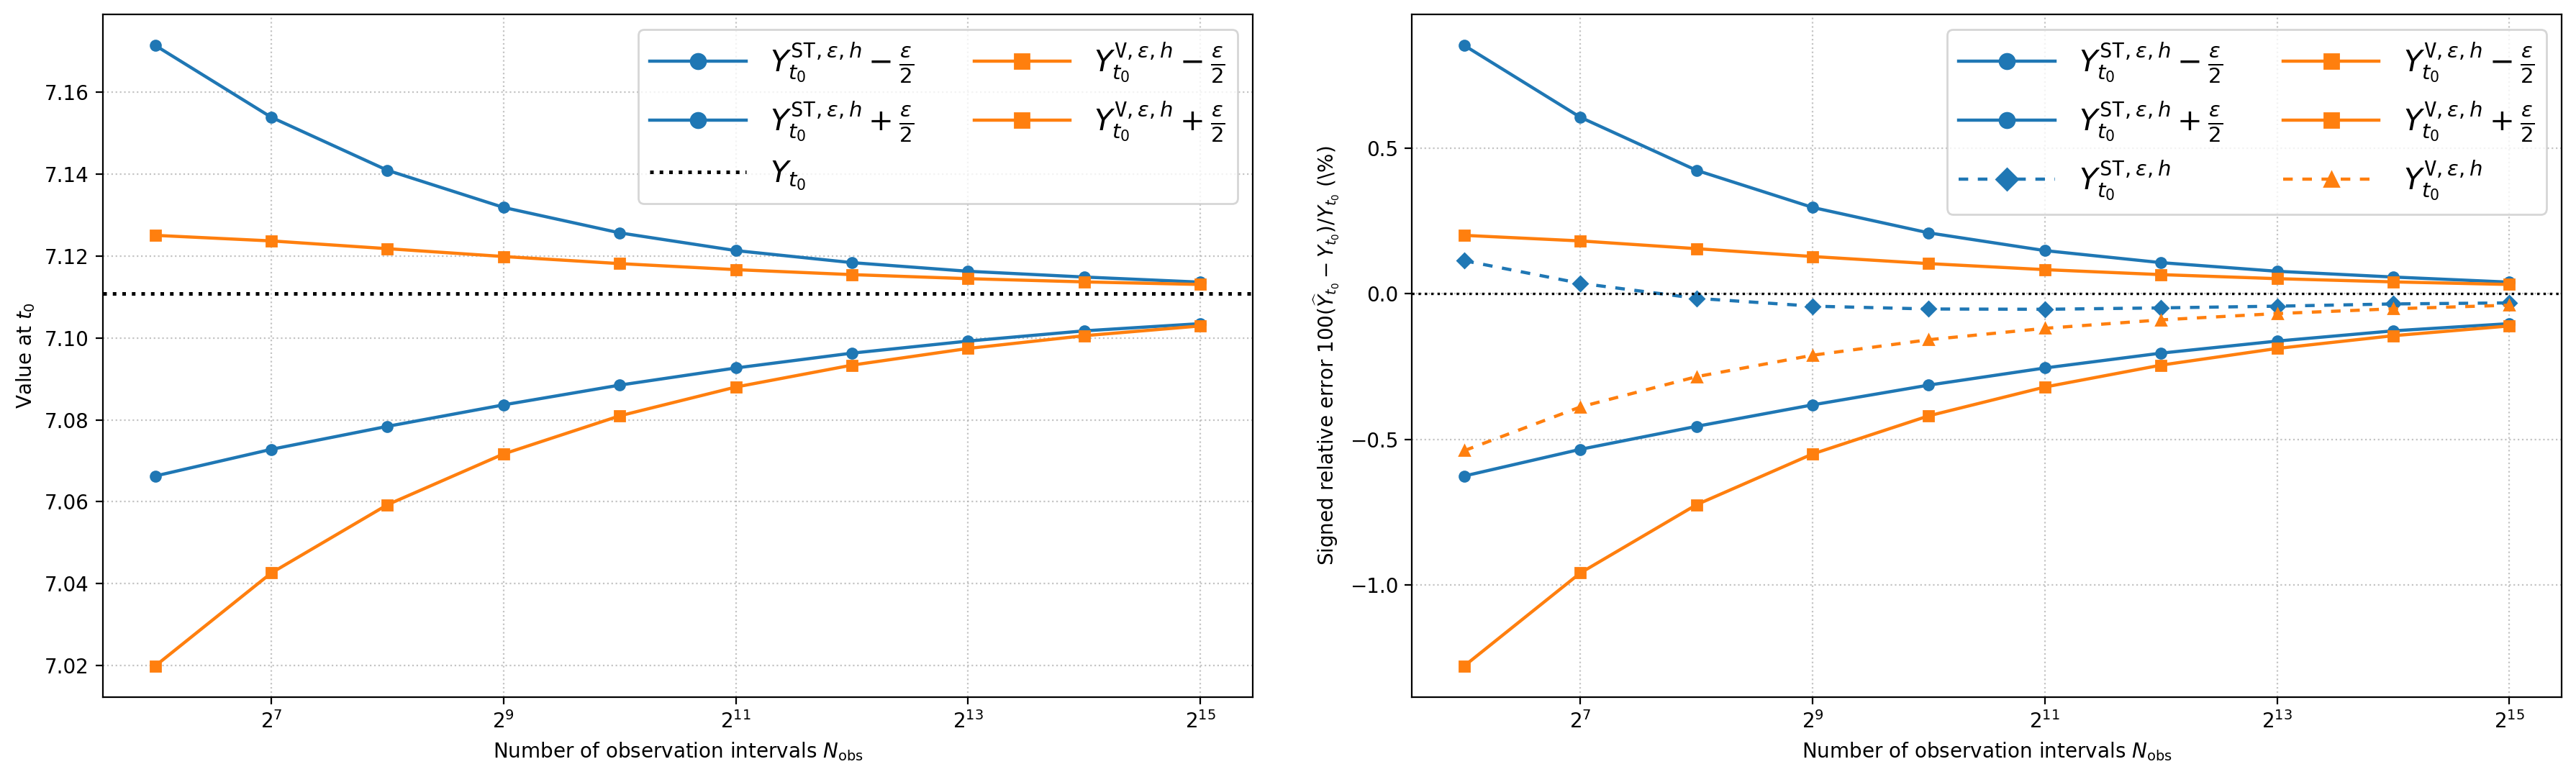

(<Figure size 3600x1100 with 2 Axes>,
 (<Axes: xlabel='Number of observation intervals $N_{\\mathrm{obs}}$', ylabel='Value at $t_0$'>,
  <Axes: xlabel='Number of observation intervals $N_{\\mathrm{obs}}$', ylabel='Signed relative error $100(\\widehat{Y}_{t_0}-Y_{t_0})/Y_{t_0}$ (\\%)'>))

In [9]:
# Use one epsilon scaling for both the value and relative-error figures.
stopping_exp = ExperimentConfig(
    model=base_model,
    generator=GeneratorConfig(epsilon_constant=0.5, epsilon_power=3 / 8),
    implicit_solver=implicit_solver,
    N_obs_grid=(2**6,2**7,2**8,2**9,2**10, 2**11, 2**12, 2**13, 2**14, 2**15),
)

stopping_result = run_stopping_time_experiment(stopping_exp)

plot_comparisons_side_by_side(stopping_result)